3.1
## A. CSV Data Source - California Housing

The California Housing dataset is obtained using Scikit-learn.
The dataset contains information about housing districts in California
and will be saved as a CSV file in the data/raw folder.

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Create data/raw folder if it doesn't exist
raw_folder = Path("data/raw")
raw_folder.mkdir(parents=True, exist_ok=True)

# Download California Housing dataset
housing = fetch_california_housing(as_frame=True)

# Convert to DataFrame
california_df = housing.frame

# Save as CSV
california_df.to_csv(raw_folder / "california_housing.csv", index=False)

california_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
# Load housing data from the CSV file
california_csv = pd.read_csv("data/raw/california_housing.csv")

california_csv.head()

print("Number of rows:", california_csv.shape[0])
print("Number of columns:", california_csv.shape[1])

california_csv.columns

Number of rows: 20640
Number of columns: 9


Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

In [3]:
# Dataset information(EDA)
california_csv.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
# Summary statistics
california_csv.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [5]:
# Check for missing values
california_csv.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

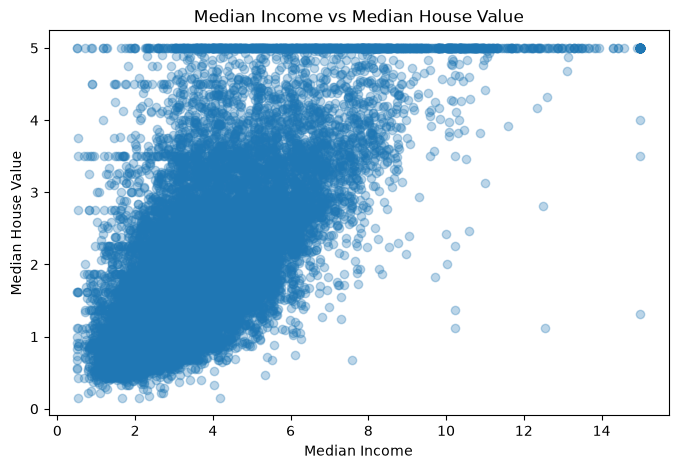

In [6]:
plt.figure(figsize=(8, 5))

plt.scatter(
    california_csv["MedInc"],
    california_csv["MedHouseVal"],
    alpha=0.3
)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value")

plt.show()

PART B
## B. Web Service (API) Data Source - Toronto, Ontario

For the web service data source, data is retrieved from the City of Toronto Open Data Portal.

The purpose of this section is to demonstrate how data can be collected from a web service using Python instead of manually downloading a file.

The `requests` library is used to communicate with the Toronto Open Data API. The returned data is then converted into a Pandas DataFrame for analysis.

Source: City of Toronto Open Data Portal

In [8]:
import requests
import pandas as pd

### Retrieve Dataset Information from the API

The Toronto Open Data API is used to retrieve information about the
Building Permits - Cleared Permits dataset.

Building permit data provides information about construction and development
activity associated with properties in Toronto.

In [9]:
package_url = (
    "https://ckan0.cf.opendata.inter.prod-toronto.ca/"
    "api/3/action/package_show"
)

params = {
    "id": "building-permits-cleared-permits"
}

response = requests.get(package_url, params=params)

print("Status code:", response.status_code)

Status code: 200


In [10]:
#convert the response to JSON format
data = response.json()

print("API Success:", data["success"])

API Success: True


In [11]:
#inspect the dataset information
dataset = data["result"]

print("Dataset:", dataset["title"])

Dataset: Building Permits - Cleared Permits


In [12]:
#Find the available resources
resources = dataset["resources"]

for resource in resources:
    print(
        resource.get("name"),
        "-",
        resource.get("format")
    )

Cleared Building Permits since 2017 - CSV
Cleared Building Permits since 2017.csv - CSV
Cleared Building Permits since 2017.xml - XML
Cleared Building Permits since 2017.json - JSON
Cleared Permits 2000 to 2016 - CSV


### Identify Available CSV Resources

The API response may contain multiple resources in different file formats.
The following step filters the available resources and identifies the CSV
files that can be loaded into Pandas for analysis.

In [13]:
# Find CSV resources
csv_resources = [
    resource
    for resource in resources
    if resource.get("format", "").upper() == "CSV"
]

print("Number of CSV resources:", len(csv_resources))
csv_resources
for resource in csv_resources:
    print(resource.get("name"))

Number of CSV resources: 3
Cleared Building Permits since 2017
Cleared Building Permits since 2017.csv
Cleared Permits 2000 to 2016


In [14]:
# Display the URL of the first CSV resource
csv_url = csv_resources[0]["url"]

print("CSV URL:")
print(csv_url)

CSV URL:
https://ckan0.cf.opendata.inter.prod-toronto.ca/datastore/dump/a96c0ba4-3026-402b-b09d-5b1268b8f810


### Load the API Data into a DataFrame

The CSV resource URL obtained from the Toronto Open Data API is loaded
directly into a Pandas DataFrame. This allows the API data to be explored
and analyzed using Python.

In [15]:
# Load the CSV resource into a Pandas DataFrame
toronto_df = pd.read_csv(csv_url)

# Display the first 5 rows
toronto_df.head()

C:\Users\pree0\AppData\Local\Temp\ipykernel_13000\638423557.py:2: DtypeWarning: Columns (2: REVISION_NUM) have mixed types. Specify dtype option on import or set low_memory=False.
  toronto_df = pd.read_csv(csv_url)


,_id,PERMIT_NUM,REVISION_NUM,PERMIT_TYPE,STRUCTURE_TYPE,WORK,STREET_NUM,STREET_NAME,STREET_TYPE,STREET_DIRECTION,...,EST_CONST_COST,ASSEMBLY,INSTITUTIONAL,RESIDENTIAL,BUSINESS_AND_PERSONAL_SERVICES,MERCANTILE,INDUSTRIAL,INTERIOR_ALTERATIONS,DEMOLITION,BUILDER_NAME
0,1,24 129621 DRN,00,Drain and Site Service,Laneway / Rear Yard Suite,Building Permit Related (DR),875,ST CLARENS,AVE,,...,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,2,24 150557 DRN,00,Drain and Site Service,SFD - Semi-Detached,Building Permit Related (DR),11,ROBLOCKE,AVE,,...,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,3,24 128096 DRN,00,Drain and Site Service,SFD - Detached,Building Permit Related (DR),22,DAVIES,CRES,,...,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,4,24 128146 DRN,00,Drain and Site Service,SFD - Detached,Back Water Valve (Sewer only),118,WOODMOUNT,AVE,,...,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,5,24 128148 DRN,00,Drain and Site Service,SFD - Detached,Back Water Valve (Sewer only),268,SCARBORO,CRES,,...,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


### Inspect the Dataset

The number of rows and columns is checked to understand the size of the
dataset. The first few records and column names are also examined to
understand the available information.

In [16]:
print("Number of rows:", toronto_df.shape[0])
print("Number of columns:", toronto_df.shape[1])

toronto_df.columns

toronto_df.info()

Number of rows: 440488
Number of columns: 32
<class 'pandas.DataFrame'>
RangeIndex: 440488 entries, 0 to 440487
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   _id                             440488 non-null  int64  
 1   PERMIT_NUM                      440488 non-null  str    
 2   REVISION_NUM                    440488 non-null  object 
 3   PERMIT_TYPE                     440488 non-null  str    
 4   STRUCTURE_TYPE                  438250 non-null  str    
 5   WORK                            440411 non-null  str    
 6   STREET_NUM                      440483 non-null  str    
 7   STREET_NAME                     440483 non-null  str    
 8   STREET_TYPE                     440488 non-null  str    
 9   STREET_DIRECTION                440488 non-null  str    
 10  POSTAL                          440488 non-null  str    
 11  GEO_ID                          431128 non-n

In [17]:
toronto_df.isnull().sum()

_id                                    0
PERMIT_NUM                             0
REVISION_NUM                           0
PERMIT_TYPE                            0
STRUCTURE_TYPE                      2238
WORK                                  77
STREET_NUM                             5
STREET_NAME                            5
STREET_TYPE                            0
STREET_DIRECTION                       0
POSTAL                                 0
GEO_ID                              9360
WARD_GRID                              5
APPLICATION_DATE                       6
ISSUED_DATE                        34767
COMPLETED_DATE                         0
STATUS                                 0
DESCRIPTION                          635
CURRENT_USE                        30154
PROPOSED_USE                       28136
DWELLING_UNITS_CREATED            284301
DWELLING_UNITS_LOST               285698
EST_CONST_COST                     17805
ASSEMBLY                               0
INSTITUTIONAL   

### Summary Statistics

Summary statistics are generated for the numerical columns to understand
their distribution, range, mean, and other basic characteristics.

In [18]:
toronto_df.describe()

,_id,GEO_ID,DWELLING_UNITS_CREATED,DWELLING_UNITS_LOST,ASSEMBLY,INSTITUTIONAL,RESIDENTIAL,BUSINESS_AND_PERSONAL_SERVICES,MERCANTILE,INDUSTRIAL,INTERIOR_ALTERATIONS,DEMOLITION
count,440488.000000,4.311280e+05,156187.000000,154790.000000,440488.000000,440488.000000,440488.000000,4.404880e+05,440488.000000,440488.000000,440487.000000,440488.000000
mean,220244.500000,6.107003e+06,0.903007,0.091608,2.334771,0.995164,35.682125,1.503608e+01,1.397807,11.743302,38.401152,15.060842
std,127158.077025,6.960176e+06,17.094537,1.674886,120.218503,368.072469,868.585588,7.547233e+03,85.059035,498.167823,430.776511,492.709523
min,1.000000,1.000000e+00,-13.000000,0.000000,0.000000,0.000000,-148.618000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,110122.750000,7.646490e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
50%,220244.500000,3.563882e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
75%,330366.250000,9.278370e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
max,440488.000000,6.003081e+07,1531.000000,275.000000,28225.000000,235000.000000,128902.000000,5.000000e+06,21105.330000,126213.400000,123303.000000,124267.430000


In [19]:
toronto_df.columns

Index(['_id', 'PERMIT_NUM', 'REVISION_NUM', 'PERMIT_TYPE', 'STRUCTURE_TYPE',
       'WORK', 'STREET_NUM', 'STREET_NAME', 'STREET_TYPE', 'STREET_DIRECTION',
       'POSTAL', 'GEO_ID', 'WARD_GRID', 'APPLICATION_DATE', 'ISSUED_DATE',
       'COMPLETED_DATE', 'STATUS', 'DESCRIPTION', 'CURRENT_USE',
       'PROPOSED_USE', 'DWELLING_UNITS_CREATED', 'DWELLING_UNITS_LOST',
       'EST_CONST_COST', 'ASSEMBLY', 'INSTITUTIONAL', 'RESIDENTIAL',
       'BUSINESS_AND_PERSONAL_SERVICES', 'MERCANTILE', 'INDUSTRIAL',
       'INTERIOR_ALTERATIONS', 'DEMOLITION', 'BUILDER_NAME'],
      dtype='str')

### Basic Exploration of Toronto Building Permit Data

The Toronto API dataset contains building permit and property-related
information, including permit type, structure type, residential use,
dwelling units, and estimated construction cost.

Basic exploratory analysis is performed to understand the structure,
missing values, and numerical characteristics of the dataset.

In [20]:
print("Number of rows:", toronto_df.shape[0])
print("Number of columns:", toronto_df.shape[1])

toronto_df.info()

Number of rows: 440488
Number of columns: 32
<class 'pandas.DataFrame'>
RangeIndex: 440488 entries, 0 to 440487
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   _id                             440488 non-null  int64  
 1   PERMIT_NUM                      440488 non-null  str    
 2   REVISION_NUM                    440488 non-null  object 
 3   PERMIT_TYPE                     440488 non-null  str    
 4   STRUCTURE_TYPE                  438250 non-null  str    
 5   WORK                            440411 non-null  str    
 6   STREET_NUM                      440483 non-null  str    
 7   STREET_NAME                     440483 non-null  str    
 8   STREET_TYPE                     440488 non-null  str    
 9   STREET_DIRECTION                440488 non-null  str    
 10  POSTAL                          440488 non-null  str    
 11  GEO_ID                          431128 non-n

In [21]:
toronto_df["RESIDENTIAL"].value_counts(dropna=False)

RESIDENTIAL
0.00         400659
1.00            372
10.00           284
5.00            179
20.00           127
              ...  
1132.64           1
620.90            1
642.50            1
1544.00           1
125872.50         1
Name: count, Length: 17186, dtype: int64

In [24]:
toronto_df[
    [
        "PERMIT_TYPE",
        "STRUCTURE_TYPE",
        "CURRENT_USE",
        "PROPOSED_USE",
        "DWELLING_UNITS_CREATED",
        "EST_CONST_COST",
        "RESIDENTIAL"
    ]
].head(10)

,PERMIT_TYPE,STRUCTURE_TYPE,CURRENT_USE,PROPOSED_USE,DWELLING_UNITS_CREATED,EST_CONST_COST,RESIDENTIAL
0,Drain and Site Service,Laneway / Rear Yard Suite,Sfd Detached,Sfd Detached W/ Laneway Suite,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0
1,Drain and Site Service,SFD - Semi-Detached,Sfd - Semi Detached,Sfd - Semi Detached,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0
2,Drain and Site Service,SFD - Detached,Sfd-Detached,Sfd-Detached,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0
3,Drain and Site Service,SFD - Detached,Single Family,Single Family,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0
4,Drain and Site Service,SFD - Detached,Single Family,Single Family,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0
5,Drain and Site Service,SFD - Semi-Detached,Semi-Detached,Semi-Detached,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0
6,Drain and Site Service,SFD - Detached,Single Family,Single Family,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0
7,Drain and Site Service,SFD - Detached,Single Family,Single Family,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0
8,Drain and Site Service,SFD - Detached,Sfd,Sfd,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0
9,Drain and Site Service,SFD - Detached,Sfd,Sfd,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD,0.0


In [25]:
toronto_df["STRUCTURE_TYPE"].value_counts().head(20)


STRUCTURE_TYPE
SFD - Detached                      171067
SFD - Semi-Detached                  40085
Office                               36638
SFD - Townhouse                      24469
Apartment Building                   18635
2 Unit - Detached                    14602
Retail Store                         14124
First Party                          11108
Multiple Unit Building               11101
Stacked Townhouses                    9492
Multiple Use/Non Residential          8007
Restaurant 30 Seats or Less           6916
Other                                 6893
2 Unit - Semi-detached                5685
Restaurant Greater Than 30 Seats      5439
Industrial                            4935
Laneway / Rear Yard Suite             4097
Mixed Use/Res w Non Res               3337
3+ Unit - Detached                    3312
Medical/Dental Office                 3308
Name: count, dtype: int64

In [26]:
toronto_df["EST_CONST_COST"].head(10)


0    DO NOT UPDATE OR DELETE THIS INFO FIELD
1    DO NOT UPDATE OR DELETE THIS INFO FIELD
2    DO NOT UPDATE OR DELETE THIS INFO FIELD
3    DO NOT UPDATE OR DELETE THIS INFO FIELD
4    DO NOT UPDATE OR DELETE THIS INFO FIELD
5    DO NOT UPDATE OR DELETE THIS INFO FIELD
6    DO NOT UPDATE OR DELETE THIS INFO FIELD
7    DO NOT UPDATE OR DELETE THIS INFO FIELD
8    DO NOT UPDATE OR DELETE THIS INFO FIELD
9    DO NOT UPDATE OR DELETE THIS INFO FIELD
Name: EST_CONST_COST, dtype: str

In [27]:
print(toronto_df["EST_CONST_COST"].dtype)

str


In [28]:
toronto_df[
    ["STRUCTURE_TYPE", "DWELLING_UNITS_CREATED", "EST_CONST_COST"]
].head(20)

,STRUCTURE_TYPE,DWELLING_UNITS_CREATED,EST_CONST_COST
0,Laneway / Rear Yard Suite,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD
1,SFD - Semi-Detached,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD
2,SFD - Detached,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD
3,SFD - Detached,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD
4,SFD - Detached,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD
5,SFD - Semi-Detached,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD
6,SFD - Detached,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD
7,SFD - Detached,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD
8,SFD - Detached,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD
9,SFD - Detached,NaN,DO NOT UPDATE OR DELETE THIS INFO FIELD


In [30]:
# Convert estimated construction cost to numeric
toronto_df["EST_CONST_COST"] = pd.to_numeric(
    toronto_df["EST_CONST_COST"],
    errors="coerce"
)

toronto_df["EST_CONST_COST"].describe()

count    1.470360e+05
mean     3.375860e+05
std      5.626175e+06
min      0.000000e+00
25%      0.000000e+00
50%      1.200000e+04
75%      1.000000e+05
max      1.000000e+09
Name: EST_CONST_COST, dtype: float64

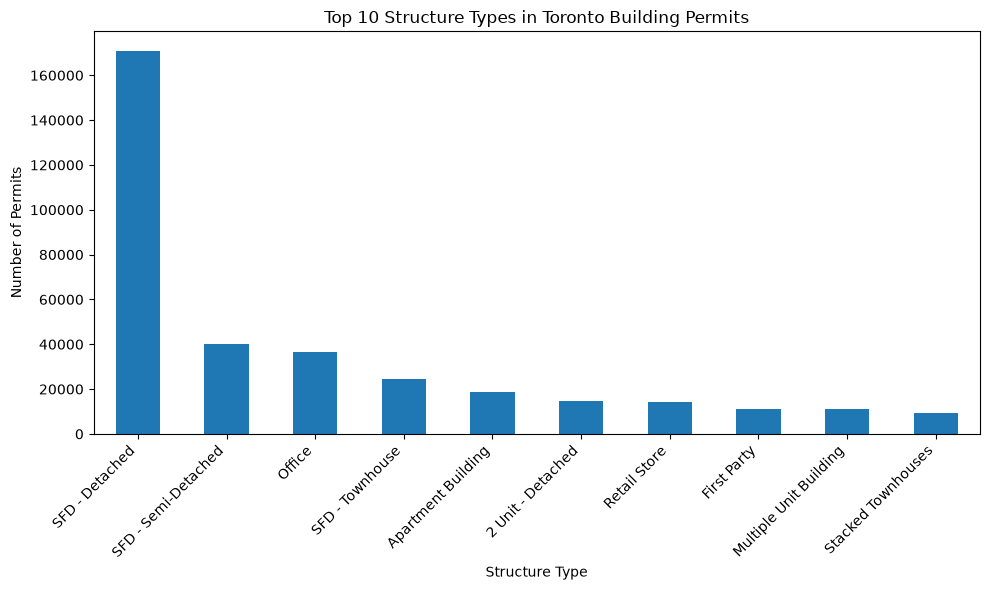

In [31]:
import matplotlib.pyplot as plt

structure_counts = toronto_df["STRUCTURE_TYPE"].value_counts().head(10)

plt.figure(figsize=(10, 6))
structure_counts.plot(kind="bar")

plt.title("Top 10 Structure Types in Toronto Building Permits")
plt.xlabel("Structure Type")
plt.ylabel("Number of Permits")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

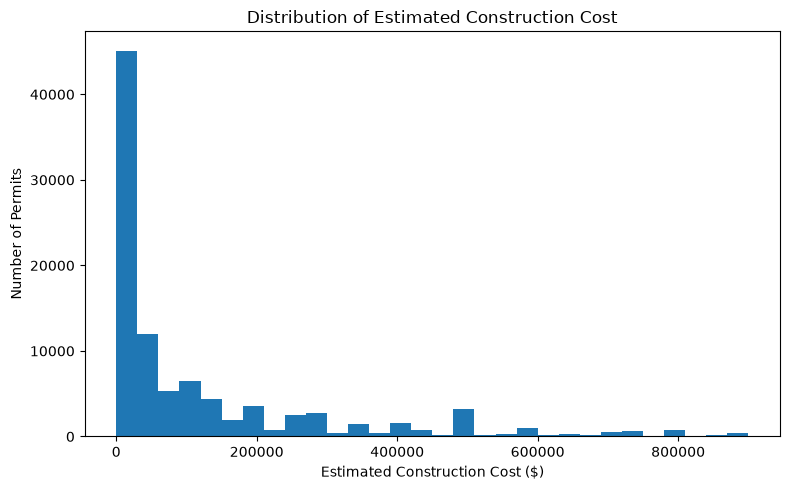

In [32]:
# Keep valid positive construction costs
cost_data = toronto_df.loc[
    toronto_df["EST_CONST_COST"] > 0,
    "EST_CONST_COST"
].dropna()

# Remove extreme values from the visualization
upper_limit = cost_data.quantile(0.95)
cost_plot_data = cost_data[cost_data <= upper_limit]

plt.figure(figsize=(8, 5))

plt.hist(cost_plot_data, bins=30)

plt.title("Distribution of Estimated Construction Cost")
plt.xlabel("Estimated Construction Cost ($)")
plt.ylabel("Number of Permits")

plt.tight_layout()
plt.show()

### Dwelling Units Created

The number of dwelling units created through building permits is examined
to understand how the dataset represents residential development activity.

In [33]:
toronto_df["DWELLING_UNITS_CREATED"] = pd.to_numeric(
    toronto_df["DWELLING_UNITS_CREATED"],
    errors="coerce"
)

toronto_df["DWELLING_UNITS_CREATED"].describe()

count    156187.000000
mean          0.903007
std          17.094537
min         -13.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        1531.000000
Name: DWELLING_UNITS_CREATED, dtype: float64

PART C
## Relational Database Data Source - SQLite

For the relational database source, SQLite is used to store and retrieve
the California Housing dataset.

The housing data is inserted into a relational database table and SQL
queries are used to retrieve and filter the records.

SQLite is used because it is lightweight, portable, and does not require
a separate database server.

In [34]:
import sqlite3
import pandas as pd
from pathlib import Path

In [35]:
# Create database folder if it does not exist
db_folder = Path("data/database")
db_folder.mkdir(parents=True, exist_ok=True)

db_path = db_folder / "housing.db"

print("Database path:", db_path)

Database path: data\database\housing.db


In [36]:
california_df = pd.read_csv(
    "data/raw/california_housing.csv"
)

california_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [37]:
#connect to the SQLite database

# Connect to SQLite database
conn = sqlite3.connect(db_path)

print("Connected to SQLite database successfully.")

Connected to SQLite database successfully.


In [38]:
#store the California Housing DataFrame in the SQLite database

california_df.to_sql(
    "california_housing",
    conn,
    if_exists="replace",
    index=False
)

print("Housing data stored successfully.")

Housing data stored successfully.


In [39]:
# Querry data from the SQLite database
 
query = """
SELECT *
FROM california_housing;
"""

housing_db_df = pd.read_sql_query(query, conn)

housing_db_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [40]:
# this query retrieves areas where the median house value is
# greater than 3

query_filtered = """
SELECT
    MedInc,
    HouseAge,
    AveRooms,
    MedHouseVal
FROM california_housing
WHERE MedHouseVal > 3;
"""

filtered_housing_df = pd.read_sql_query(
    query_filtered,
    conn
)

filtered_housing_df.head()

,MedInc,HouseAge,AveRooms,MedHouseVal
0,8.3252,41.0,6.984127,4.526
1,8.3014,21.0,6.238137,3.585
2,7.2574,52.0,8.288136,3.521
3,5.6431,52.0,5.817352,3.413
4,3.8462,52.0,6.281853,3.422


In [41]:
print("Number of filtered records:", filtered_housing_df.shape[0])

filtered_housing_df.head()

Number of filtered records: 3836


,MedInc,HouseAge,AveRooms,MedHouseVal
0,8.3252,41.0,6.984127,4.526
1,8.3014,21.0,6.238137,3.585
2,7.2574,52.0,8.288136,3.521
3,5.6431,52.0,5.817352,3.413
4,3.8462,52.0,6.281853,3.422


In [42]:
# basic EDA

print("Number of filtered records:", filtered_housing_df.shape[0])

filtered_housing_df.head()

Number of filtered records: 3836


,MedInc,HouseAge,AveRooms,MedHouseVal
0,8.3252,41.0,6.984127,4.526
1,8.3014,21.0,6.238137,3.585
2,7.2574,52.0,8.288136,3.521
3,5.6431,52.0,5.817352,3.413
4,3.8462,52.0,6.281853,3.422


In [43]:
# basic EDA

housing_db_df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

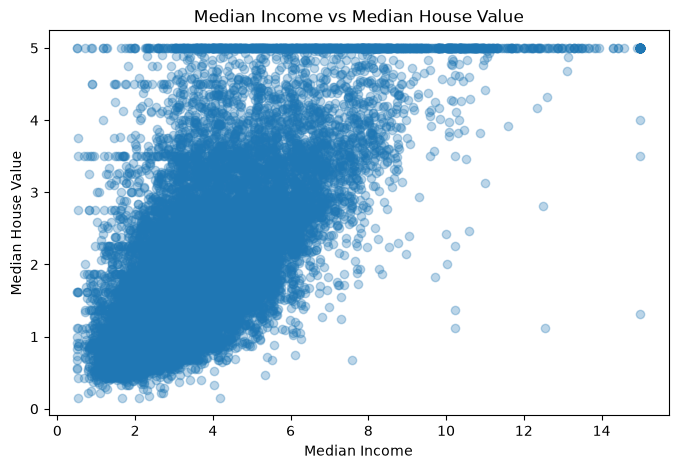

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    housing_db_df["MedInc"],
    housing_db_df["MedHouseVal"],
    alpha=0.3
)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value")

plt.show()

In [45]:
# close connection to the SQLite database
conn.close()

print("Database connection closed.")

Database connection closed.


# Section 3.2 — Univariate Linear Regression

This notebook implements univariate linear regression using **one predictor** to predict house prices. It covers the complete workflow required for Session 1:

1. Define the prediction problem
2. Preprocess the data: missing values, train/test split, and standardization
3. Implement linear regression **from scratch** using MSE cost and gradient descent
4. Implement the same model with `scikit-learn` for comparison
5. Evaluate both models using RMSE, MAE, and $R^2$
6. Plot the regression line against the observed data

**Dataset:** California housing data stored at `data/raw/california_housing.csv`.


In [47]:


# Load the dataset
df = pd.read_csv("data/raw/california_housing.csv")

# Remove accidental whitespace from column names
df.columns = df.columns.str.strip()

print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Dataset shape: (20640, 9)
Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 1. Define the Problem

We use **median income (`MedInc`)** as the single predictor $X$ and **median house value (`MedHouseVal`)** as the target $y$.

The goal is to learn a linear relationship that can predict house value from median income.

The univariate linear regression hypothesis is:

$$
h_\theta(x) = \theta_0 + \theta_1x
$$

where:
- $\theta_0$ is the intercept
- $\theta_1$ is the slope
- $x$ is the predictor
- $h_\theta(x)$ is the predicted house value.


## Select Columns

In [48]:
feature = "MedInc"
target = "MedHouseVal"

X = df[[feature]].values
y = df[target].values

print("Predictor:", feature)
print("Target:", target)
print("Number of observations:", len(y))


Predictor: MedInc
Target: MedHouseVal
Number of observations: 20640


## 2. Preprocessing

The preprocessing steps are:

1. Check for missing values.
2. Remove rows with missing values in the predictor or target.
3. Split the data into training and testing sets.
4. Standardize the predictor using `StandardScaler`.

The train/test split is performed **before** fitting the scaler. This prevents information from the test set from influencing the preprocessing step (data leakage). The scaler is fitted only on the training data and then applied to both training and test data.


In [49]:
# Check missing values before cleaning
print("Missing values before cleaning:")
print(df[[feature, target]].isna().sum())

# Remove rows with missing predictor or target values
df_clean = df.dropna(subset=[feature, target]).copy()

X = df_clean[[feature]].values
y = df_clean[target].values

print("\nObservations after removing missing values:", len(y))
print("Missing values after cleaning:")
print(df_clean[[feature, target]].isna().sum())

# Train/test split: 80% training, 20% testing
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize using training data only
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training mean after scaling:", X_train.mean())
print("Training standard deviation after scaling:", X_train.std())

X_train[:5], y_train[:5]


Missing values before cleaning:
MedInc         0
MedHouseVal    0
dtype: int64

Observations after removing missing values: 20640
Missing values after cleaning:
MedInc         0
MedHouseVal    0
dtype: int64

Training samples: 16512
Testing samples: 4128
Training mean after scaling: -6.411753126711176e-17
Training standard deviation after scaling: 0.9999999999999999


(array([[-0.326196  ],
        [-0.03584338],
        [ 0.14470145],
        [-1.01786438],
        [-0.17148831]]),
 array([1.03 , 3.821, 1.726, 0.934, 0.965]))

## 3. Linear Regression From Scratch

### Hypothesis

For one predictor, the model is:

$$
h_\theta(x) = \theta_0 + \theta_1x
$$

### Mean Squared Error (MSE) Cost

We use the MSE cost function to measure how far the predictions are from the true target values:

$$
J(\theta_0,\theta_1) = \frac{1}{m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)})-y^{(i)}\right)^2
$$

where $m$ is the number of training observations.

### Gradient Descent

The gradients are:

$$
\frac{\partial J}{\partial\theta_0} = \frac{2}{m}\sum_{i=1}^{m}(h_\theta(x^{(i)})-y^{(i)})
$$

$$
\frac{\partial J}{\partial\theta_1} = \frac{2}{m}\sum_{i=1}^{m}(h_\theta(x^{(i)})-y^{(i)})x^{(i)}
$$

The parameters are updated repeatedly using:

$$
\theta_j \leftarrow \theta_j - \alpha\frac{\partial J}{\partial\theta_j}
$$

where $\alpha$ is the learning rate.

In [50]:
def gradient_descent(X, y, learning_rate=0.01, iterations=1000):
    """Train univariate linear regression using gradient descent."""
    m = len(y)
    X = X.flatten()

    # Initialize parameters
    theta0 = 0.0
    theta1 = 0.0

    cost_history = []

    for _ in range(iterations):
        # Hypothesis / predictions
        y_pred = theta0 + theta1 * X

        # Error
        error = y_pred - y

        # MSE cost
        mse = (1 / m) * np.sum(error ** 2)
        cost_history.append(mse)

        # Gradients
        d_theta0 = (2 / m) * np.sum(error)
        d_theta1 = (2 / m) * np.sum(error * X)

        # Gradient descent updates
        theta0 -= learning_rate * d_theta0
        theta1 -= learning_rate * d_theta1

    return theta0, theta1, cost_history


# Train the scratch model
theta0, theta1, cost_history = gradient_descent(
    X_train,
    y_train,
    learning_rate=0.01,
    iterations=1000
)

print("theta_0 (intercept):", theta0)
print("theta_1 (slope):", theta1)
print("Final MSE:", cost_history[-1])

theta_0 (intercept): 2.071946933891858
theta_1 (slope): 0.7985195630821527
Final MSE: 0.6991447170182824


### Gradient Descent Convergence

The cost should generally decrease as the gradient descent iterations progress. This plot shows the MSE cost recorded during training.

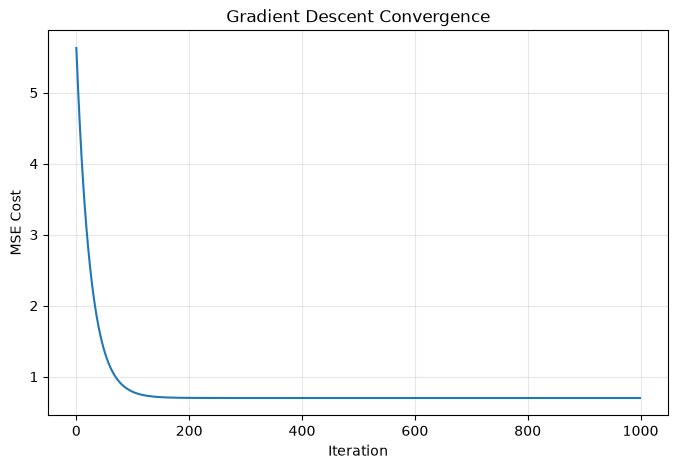

In [51]:
plt.figure(figsize=(8, 5))
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("MSE Cost")
plt.title("Gradient Descent Convergence")
plt.grid(alpha=0.3)
plt.show()


## 4. Linear Regression With Scikit-Learn

For comparison, we train `sklearn.linear_model.LinearRegression` using the same training and testing data.

In [52]:
model = LinearRegression()
model.fit(X_train, y_train)

sk_theta0 = model.intercept_
sk_theta1 = model.coef_[0]

print("Scikit-learn intercept:", sk_theta0)
print("Scikit-learn slope:", sk_theta1)

Scikit-learn intercept: 2.071946937378876
Scikit-learn slope: 0.7985195644260356


## 5. Evaluation

Both models are evaluated on the **test set**, which was not used during training.

We use three metrics:

- **RMSE (Root Mean Squared Error):** measures prediction error in the target's units and penalizes larger errors more strongly.
- **MAE (Mean Absolute Error):** measures the average absolute prediction error.
- **$R^2$ (coefficient of determination):** measures how much of the variation in the target is explained by the model.

In [53]:
def evaluate_model(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }


# Predictions on the test set
y_pred_scratch = theta0 + theta1 * X_test.flatten()
y_pred_sklearn = model.predict(X_test)

# Evaluate both models
scratch_metrics = evaluate_model(y_test, y_pred_scratch)
sklearn_metrics = evaluate_model(y_test, y_pred_sklearn)

results = pd.DataFrame(
    [scratch_metrics, sklearn_metrics],
    index=["From Scratch", "Scikit-Learn"]
)

results


,MSE,RMSE,MAE,R2
From Scratch,0.709116,0.84209,0.629909,0.458859
Scikit-Learn,0.709116,0.84209,0.629909,0.458859


### Interpreting the Results

The scratch implementation and the scikit-learn implementation should produce very similar coefficients and evaluation metrics because both models are fitting the same linear relationship to the same training data.

Small numerical differences can occur because the scratch implementation uses a finite number of gradient descent iterations, while `LinearRegression` uses a direct least-squares solution.

## 6. Regression Line vs. Observed Data

The scatter plot below shows the test observations together with the regression lines learned by the scratch implementation and scikit-learn.

The predictor shown on the x-axis is standardized `MedInc`, because the models were trained using the standardized feature.

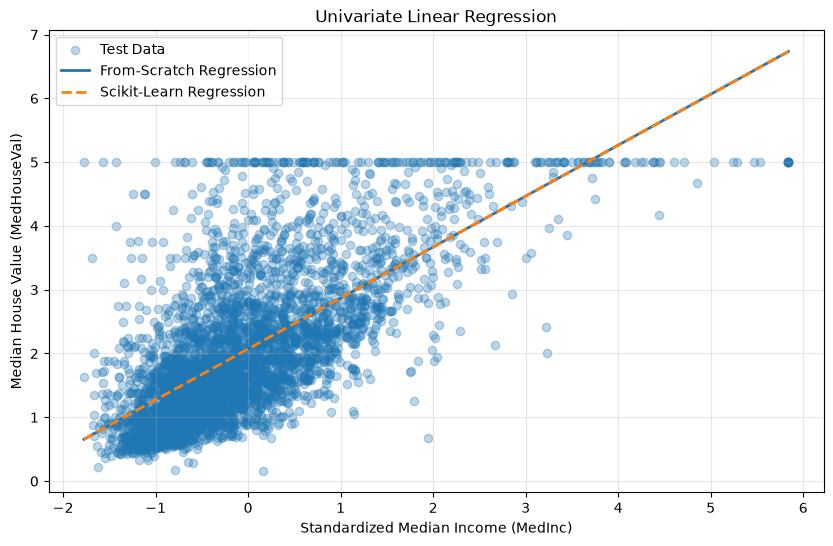

In [54]:
# Sort x-values so the regression lines are plotted cleanly
order = np.argsort(X_test.flatten())
X_test_sorted = X_test.flatten()[order]

y_scratch_sorted = y_pred_scratch[order]
y_sklearn_sorted = y_pred_sklearn[order]

plt.figure(figsize=(10, 6))

plt.scatter(
    X_test.flatten(),
    y_test,
    alpha=0.3,
    label="Test Data"
)

plt.plot(
    X_test_sorted,
    y_scratch_sorted,
    linewidth=2,
    label="From-Scratch Regression"
)

plt.plot(
    X_test_sorted,
    y_sklearn_sorted,
    linewidth=2,
    linestyle="--",
    label="Scikit-Learn Regression"
)

plt.xlabel("Standardized Median Income (MedInc)")
plt.ylabel("Median House Value (MedHouseVal)")
plt.title("Univariate Linear Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()